In [1]:
import tensorflow as tf
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
import re
from datetime import datetime
from datetime import timedelta

2026-08-06 15:31:17.078585: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
gemlam_dir = "/results/forcing/atmospheric/GEM2.5/gemlam"
operational_dir = "/results/forcing/atmospheric/GEM2.5/operational"
time_fixed_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/TimeFixed"

gemlam_start = datetime(2007, 1, 3)
gemlam_end = datetime(2014, 9, 30)
ops_start = datetime(2014, 10, 1)
ops_end = datetime(2021, 12, 31)

years = range(2007, 2022)

fixed_filenames = {
    "gemlam_y2008m07d16.nc",
    "gemlam_y2008m07d17.nc",
    "gemlam_y2008m07d18.nc",
    "gemlam_y2008m07d19.nc",
    "gemlam_y2008m07d20.nc",
    "gemlam_y2008m07d21.nc",
    "gemlam_y2008m07d22.nc",
    "gemlam_y2008m07d23.nc",
    "gemlam_y2008m08d10.nc",
    "gemlam_y2008m08d11.nc",
    "gemlam_y2008m08d12.nc",
    "gemlam_y2012m10d04.nc"   
}

def get_file_date(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r"_y(\d{4})m(\d{2})d(\d{2})", filename)
    if match is None:
        return None
    year, month, day = map(int, match.groups())
    return datetime(year, month, day)

all_gemlam_files = glob.glob(os.path.join(gemlam_dir, "*.nc"))
all_ops_files = glob.glob(os.path.join(operational_dir, "ops_y????m??d??.nc"))

selected_gemlam_files = {}

for filepath in all_gemlam_files:
    file_date = get_file_date(filepath)
    if file_date is not None and gemlam_start <= file_date <= gemlam_end:
        selected_gemlam_files[file_date] = filepath

for filename in fixed_filenames:
    fixed_filepath = os.path.join(time_fixed_dir, filename)
    if not os.path.exists(fixed_filepath):
        raise FileNotFoundError(f"Corrected file not found: {fixed_filepath}")
    fixed_date = get_file_date(fixed_filepath)
    if fixed_date is None:
        raise ValueError(f"Could not extract date from: {fixed_filepath}")
    selected_gemlam_files[fixed_date] = fixed_filepath

selected_ops_files = {}

for filepath in all_ops_files:
    file_date = get_file_date(filepath)
    if file_date is not None and ops_start <= file_date <= ops_end:
        selected_ops_files[file_date] = filepath

all_selected_files = {**selected_gemlam_files, **selected_ops_files}

hrdps_files_by_year = {}

for year in years:
    files = [filepath for file_date, filepath in sorted(all_selected_files.items()) if file_date.year == year]
    if len(files) == 0:
        print(f"{year}: no files found")
        continue
    hrdps_files_by_year[year] = files
    print(year, ":", files[0], "to", files[-1], f"({len(files)} files)")

2007 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d03.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m12d31.nc (363 files)
2008 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m12d31.nc (366 files)
2009 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m12d31.nc (365 files)
2010 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m12d31.nc (365 files)
2011 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m12d31.nc (365 files)
2012 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m12d31.nc (366 files)
2013 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2013m01d01.nc to /results/forc

In [3]:
# Loading datasets

weights_pre_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
weights_post_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_22sep11onward.nc"
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"

ds_weights_pre = xr.open_dataset(weights_pre_file).load()
ds_weights_post = xr.open_dataset(weights_post_file).load()

with xr.open_dataset(mesh_mask_file) as ds_mesh:
    nemo_lat = ds_mesh["nav_lat"].load()
    nemo_lon = ds_mesh["nav_lon"].load()

In [4]:
# Converts hourly HRDPS from the 266 × 256 HRDPS grid to the 898 × 398 NEMO grid

transition_time = pd.Timestamp("2011-09-22 00:00:00")

def interpolate_atmpres_with_weights(atmpres, ds_weights):
    atmpres = atmpres.transpose("time_counter", "y", "x")

    n_time = atmpres.sizes["time_counter"]
    source_shape = (atmpres.sizes["y"],atmpres.sizes["x"])
    n_source_cells = source_shape[0] * source_shape[1]

    source_values = (atmpres.values.reshape(n_time, n_source_cells).astype(np.float32))
    target_shape = ds_weights["src01"].shape

    interpolated = np.zeros((n_time, target_shape[0], target_shape[1]),dtype=np.float32)

    for n in range(1, 5):
        # The source indexes in the weights file are 1-based
        source_index = (ds_weights[f"src{n:02d}"].values.astype(np.int64)- 1)
        weight = (ds_weights[f"wgt{n:02d}"].values.astype(np.float32))

        interpolated += (source_values[:, source_index]* weight[None, :, :])

    atmpres_nemo = xr.DataArray(
        interpolated,
        dims=("time_counter", "y", "x"),
        coords={
            "time_counter": atmpres["time_counter"],
            "nav_lat": (("y", "x"), nemo_lat.values),
            "nav_lon": (("y", "x"), nemo_lon.values),
        },
        name="atmpres"
    )

    atmpres_nemo.attrs = atmpres.attrs.copy()
    atmpres_nemo.attrs["grid"] = "SalishSeaCast NEMO grid"
    atmpres_nemo.attrs["interpolation"] = (
        "Four-source weighted HRDPS-to-NEMO interpolation"
    )
    return atmpres_nemo

In [5]:
# Open file and interpolates

def extract_and_interpolate_hourly_atmpres(file):
    with xr.open_dataset(file) as ds:
        atmpres = ds["atmpres"].sortby("time_counter")
        time_index = atmpres.get_index("time_counter")

        if time_index.has_duplicates:
            unique_mask = ~time_index.duplicated()
            atmpres = atmpres.isel(time_counter=unique_mask)

        atmpres = atmpres.load()

    times = pd.to_datetime(atmpres["time_counter"].values)

    before_transition = times < transition_time
    after_transition = times >= transition_time

    pieces = []

    if before_transition.any():
        atmpres_pre = atmpres.isel(time_counter=np.where(before_transition)[0])
        interpolated_pre = interpolate_atmpres_with_weights(atmpres_pre,ds_weights_pre)
        pieces.append(interpolated_pre)

    if after_transition.any():
        atmpres_post = atmpres.isel(time_counter=np.where(after_transition)[0])
        interpolated_post = interpolate_atmpres_with_weights(atmpres_post,ds_weights_post)
        pieces.append(interpolated_post)

    atmpres_nemo = xr.concat(pieces,dim="time_counter").sortby("time_counter")
    return atmpres_nemo

In [6]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (ds_mesh["tmask"].isel(t=0, z=0).load().values.astype(bool))
    nemo_lat_2d = ds_mesh["nav_lat"].load().values
    nemo_lon_2d = ds_mesh["nav_lon"].load().values
nemo_j, nemo_i = np.where(water_mask)
water_flat_indices = np.flatnonzero(water_mask.reshape(-1))
nemo_water_lat = nemo_lat_2d[water_mask]
nemo_water_lon = nemo_lon_2d[water_mask]
n_water = len(water_flat_indices)
print("NEMO grid shape:", water_mask.shape)
print("Number of surface water cells:", n_water)

NEMO grid shape: (898, 398)
Number of surface water cells: 81383


In [7]:
def process_daily_file_to_3h_water(file):
    atmpres_nemo_hourly = extract_and_interpolate_hourly_atmpres(file)
    n_time = atmpres_nemo_hourly.sizes["time_counter"]

    atmpres_water_values = (atmpres_nemo_hourly.values.reshape(n_time, -1)[:, water_flat_indices].astype(np.float32))
    atmpres_water_hourly = xr.DataArray(atmpres_water_values,dims=("time_counter", "water_cell"),coords={
            "time_counter": atmpres_nemo_hourly["time_counter"].values,
            "water_cell": np.arange(n_water, dtype=np.int32),},name="atmpres",attrs=atmpres_nemo_hourly.attrs,)

    atmpres_water_3h = atmpres_water_hourly.resample(time_counter="3h",label="left",closed="left",origin="start_day",).mean()
    return atmpres_water_3h.load()

In [8]:
# # Run only once
# output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h"
# os.makedirs(output_dir, exist_ok=True)
# years = list(range(2007, 2022))
# hrdps_nemo_processed_files = []

# for year in years:
#     files = hrdps_files_by_year[year]
#     print(f"\nProcessing {year}: {len(files)} daily files")
#     daily_3h_results = []

#     for file_number, file in enumerate(files, start=1):
#         daily_3h = process_daily_file_to_3h_water(file)
#         daily_3h_results.append(daily_3h)

#         if file_number == 1 or file_number % 25 == 0 or file_number == len(files):
#             print(f"{year}: processed {file_number}/{len(files)} files")

#     atmpres_year = xr.concat(daily_3h_results, dim="time_counter").sortby("time_counter")
#     time_index = atmpres_year.get_index("time_counter")

#     if time_index.has_duplicates:
#         atmpres_year = atmpres_year.isel(time_counter=~time_index.duplicated())

#     ds_year = atmpres_year.to_dataset(name="atmpres")
#     ds_year = ds_year.assign_coords(nemo_j=("water_cell", nemo_j.astype(np.int32)), nemo_i=("water_cell", nemo_i.astype(np.int32)), nav_lat=("water_cell", nemo_water_lat.astype(np.float32)), nav_lon=("water_cell", nemo_water_lon.astype(np.float32)))
#     ds_year.attrs["description"] = "Raw hourly HRDPS atmpres interpolated onto NEMO surface water cells, then resampled to three-hourly means."

#     output_file = f"{output_dir}/HRDPS_NEMO_{year}_atmpres_3h.nc"
#     encoding = {"atmpres": {"dtype": "float32", "zlib": True, "complevel": 4}}
#     ds_year.to_netcdf(output_file, engine="netcdf4", encoding=encoding)
#     hrdps_nemo_processed_files.append(output_file)

#     print("Saved:", output_file)
#     print("Shape:", ds_year["atmpres"].shape)
#     print("Time range:", ds_year.time_counter.values[0], "to", ds_year.time_counter.values[-1])

#     del daily_3h_results
#     del atmpres_year
#     del ds_year
#     gc.collect()

In [9]:
hrdps_nemo_files = sorted(glob.glob("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h/HRDPS_NEMO_*_atmpres_3h.nc"))
ds_hrdps_nemo = xr.open_mfdataset(hrdps_nemo_files, combine="by_coords")
ds_hrdps_nemo = ds_hrdps_nemo.sortby("time_counter")

print(ds_hrdps_nemo)
print("Number of files:", len(hrdps_nemo_files))
print("First time:", ds_hrdps_nemo.time_counter.values[0])
print("Last time: ", ds_hrdps_nemo.time_counter.values[-1])
print("Shape:", ds_hrdps_nemo["atmpres"].shape)

<xarray.Dataset> Size: 13GB
Dimensions:       (time_counter: 40888, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 327kB 2007-01-03 ... 2021-12-...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nemo_i        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lat       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lon       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
Data variables:
    atmpres       (time_counter, water_cell) float32 13GB dask.array<chunksize=(363, 10173), meta=np.ndarray>
Attributes:
    description:  Raw hourly HRDPS atmpres interpolated onto NEMO surface wat...
Number of files: 14
First time: 2007-01-03T00:00:00.000000000
Last time:  2021-12-31T21:00:00.000000000
Shape: (40888, 81383)


In [10]:
train_years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
validation_years = [2007, 2008, 2009]
test_years = [2019, 2020, 2021]

In [11]:
ds_hrdps_train = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(train_years))
ds_hrdps_val = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(validation_years))
ds_hrdps_test = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(test_years))

In [12]:
canrcm_years = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
canrcm_psl_files = []

for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_psl.nc"))
    canrcm_psl_files.append(matches[0])

print("CanRCM files:")
for file in canrcm_psl_files:
    print(file)

CanRCM files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201301_201312_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201401_201412_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201501_201512_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201601_201612_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201701_201712_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201801_201812_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201901_201912_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_202001_202012_3h_psl.nc
/resul

In [13]:
ds_canrcm = xr.open_mfdataset(canrcm_psl_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
shifted_time = np.array([time_value - timedelta(hours=3)for time_value in ds_canrcm["time"].values])
ds_canrcm = ds_canrcm.assign_coords(time=("time", shifted_time))

print(ds_canrcm)
print("First timestamp:", ds_canrcm.time.values[0])
print("Last timestamp: ", ds_canrcm.time.values[-1])

/tmp/ipykernel_2726552/584150751.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_psl_files,combine="by_coords")


<xarray.Dataset> Size: 20GB
Dimensions:       (time: 43800, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 350kB 2007-01-01 00:00:00 ... 2021-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 701kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 44kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    psl           (time, rlat, rlon) float32 20GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/19)
    CDI:                            Climate Data Interface version 2.0.3 (htt...
    Conventions:                  

In [14]:
nemo_water_lat = ds_hrdps_nemo["nav_lat"].values
nemo_water_lon = ds_hrdps_nemo["nav_lon"].values

nemo_water_lon_normalized = ((nemo_water_lon + 180) % 360) - 180

lat_min = float(np.nanmin(nemo_water_lat))
lat_max = float(np.nanmax(nemo_water_lat))

lon_min = float(np.nanmin(nemo_water_lon_normalized))
lon_max = float(np.nanmax(nemo_water_lon_normalized))

print("NEMO latitude range:", lat_min, "to", lat_max)
print("NEMO longitude range:", lon_min, "to", lon_max)

NEMO latitude range: 47.06300735473633 to 50.92766571044922
NEMO longitude range: -126.14797973632812 to -122.22117614746094


In [15]:
lat_canrcm = ds_canrcm["lat"]
lon_canrcm = ds_canrcm["lon"]

lon_canrcm_normalized = ((lon_canrcm + 180) % 360) - 180
canrcm_region_mask = ((lat_canrcm >= lat_min)& (lat_canrcm <= lat_max)
                      & (lon_canrcm_normalized >= lon_min) & (lon_canrcm_normalized <= lon_max))

rlat_indices, rlon_indices = np.where(canrcm_region_mask.values)

rlat_min = rlat_indices.min()
rlat_max = rlat_indices.max()

rlon_min = rlon_indices.min()
rlon_max = rlon_indices.max()

print("CanRCM rlat indices:", rlat_min, "to", rlat_max)
print("CanRCM rlon indices:", rlon_min, "to", rlon_max)

ds_canrcm_cut = (ds_canrcm[["psl"]].isel(rlat=slice(rlat_min, rlat_max + 1),rlon=slice(rlon_min, rlon_max + 1)))
print(ds_canrcm_cut)

CanRCM rlat indices: 171 to 190
CanRCM rlon indices: 91 to 107
<xarray.Dataset> Size: 60MB
Dimensions:  (time: 43800, rlat: 20, rlon: 17)
Coordinates:
  * time     (time) object 350kB 2007-01-01 00:00:00 ... 2021-12-31 21:00:00
  * rlat     (rlat) float64 160B 2.51 2.73 2.95 3.17 ... 6.03 6.25 6.47 6.69
  * rlon     (rlon) float64 136B -19.25 -19.03 -18.81 ... -16.17 -15.95 -15.73
    lon      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
    lat      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
Data variables:
    psl      (time, rlat, rlon) float32 60MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
Attributes: (12/19)
    CDI:                            Climate Data Interface version 2.0.3 (htt...
    Conventions:                    CF-1.4
    institution:                    CCCma (Canadian Centre for Climate Modell...
    title:                          CanRCM4 model output prepared for CORDEX ...
    institute_id:      

In [16]:
ds_canrcm_train = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(train_years))
ds_canrcm_val = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(validation_years))
ds_canrcm_test = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(test_years))

In [17]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")
    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")


def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = np.array([time_to_string(t)for t in ds_canrcm_split["time"].values])
    hrdps_times = np.array([time_to_string(t)for t in ds_hrdps_split["time_counter"].values])
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    return ds_canrcm_aligned, ds_hrdps_aligned

In [18]:
canrcm_times = np.array([time_to_string(time) for time in ds_canrcm_cut["time"].values])
hrdps_times = np.array([time_to_string(time) for time in ds_hrdps_nemo["time_counter"].values])

canrcm_not_in_hrdps = np.setdiff1d(canrcm_times, hrdps_times)
hrdps_not_in_canrcm = np.setdiff1d(hrdps_times, canrcm_times)

print("CanRCM timestamps not in HRDPS:", len(canrcm_not_in_hrdps))
print(canrcm_not_in_hrdps)

print("\nHRDPS timestamps not in CanRCM:", len(hrdps_not_in_canrcm))
print(hrdps_not_in_canrcm)

CanRCM timestamps not in HRDPS: 2936
['2007-01-01 00:00:00' '2007-01-01 03:00:00' '2007-01-01 06:00:00' ...
 '2012-12-31 15:00:00' '2012-12-31 18:00:00' '2012-12-31 21:00:00']

HRDPS timestamps not in CanRCM: 24
['2008-02-29 00:00:00' '2008-02-29 03:00:00' '2008-02-29 06:00:00'
 '2008-02-29 09:00:00' '2008-02-29 12:00:00' '2008-02-29 15:00:00'
 '2008-02-29 18:00:00' '2008-02-29 21:00:00' '2016-02-29 00:00:00'
 '2016-02-29 03:00:00' '2016-02-29 06:00:00' '2016-02-29 09:00:00'
 '2016-02-29 12:00:00' '2016-02-29 15:00:00' '2016-02-29 18:00:00'
 '2016-02-29 21:00:00' '2020-02-29 00:00:00' '2020-02-29 03:00:00'
 '2020-02-29 06:00:00' '2020-02-29 09:00:00' '2020-02-29 12:00:00'
 '2020-02-29 15:00:00' '2020-02-29 18:00:00' '2020-02-29 21:00:00']


In [19]:
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)

In [20]:
print("Validation:")
print("HRDPS:", ds_hrdps_val.sizes["time_counter"])
print("CanRCM:", ds_canrcm_val.sizes["time"])
print("Training:")
print("HRDPS:", ds_hrdps_train.sizes["time_counter"])
print("CanRCM:", ds_canrcm_train.sizes["time"])
print("Testing:")
print("HRDPS:", ds_hrdps_test.sizes["time_counter"])
print("CanRCM:", ds_canrcm_test.sizes["time"])

Validation:
HRDPS: 8744
CanRCM: 8744
Training:
HRDPS: 23360
CanRCM: 23360
Testing:
HRDPS: 8760
CanRCM: 8760


In [21]:
X_hrdps_train_raw = (ds_hrdps_train["atmpres"].values.astype(np.float32))
X_hrdps_val_raw = (ds_hrdps_val["atmpres"].values.astype(np.float32))
X_hrdps_test_raw = (ds_hrdps_test["atmpres"].values.astype(np.float32))

print("Raw HRDPS-NEMO train:", X_hrdps_train_raw.shape)
print("Raw HRDPS-NEMO val:  ", X_hrdps_val_raw.shape)
print("Raw HRDPS-NEMO test: ", X_hrdps_test_raw.shape)

Raw HRDPS-NEMO train: (23360, 81383)
Raw HRDPS-NEMO val:   (8744, 81383)
Raw HRDPS-NEMO test:  (8760, 81383)


In [22]:
valid_fraction_hrdps = np.isfinite(X_hrdps_train_raw).mean(axis=0)
valid_nemo_cols = valid_fraction_hrdps > 0.95

X_hrdps_train = X_hrdps_train_raw[:, valid_nemo_cols].copy()
X_hrdps_val = X_hrdps_val_raw[:, valid_nemo_cols].copy()
X_hrdps_test = X_hrdps_test_raw[:, valid_nemo_cols].copy()

hrdps_col_mean = np.nanmean(X_hrdps_train,axis=0)

if not np.all(np.isfinite(hrdps_col_mean)):
    raise ValueError(
        "At least one retained NEMO cell has a non-finite training mean."
    )


def fill_with_training_mean(X, training_mean):
    X = X.copy()
    rows, cols = np.where(~np.isfinite(X))
    X[rows, cols] = training_mean[cols]
    return X


X_hrdps_train = fill_with_training_mean(X_hrdps_train,hrdps_col_mean)
X_hrdps_val = fill_with_training_mean(X_hrdps_val,hrdps_col_mean)
X_hrdps_test = fill_with_training_mean(X_hrdps_test,hrdps_col_mean)

print("Valid NEMO cells:", valid_nemo_cols.sum())
print("Final HRDPS train:", X_hrdps_train.shape)
print("Final HRDPS val:  ", X_hrdps_val.shape)
print("Final HRDPS test: ", X_hrdps_test.shape)

Valid NEMO cells: 81383
Final HRDPS train: (23360, 81383)
Final HRDPS val:   (8744, 81383)
Final HRDPS test:  (8760, 81383)


In [23]:
valid_water_cell = (ds_hrdps_train["water_cell"].values[valid_nemo_cols])
valid_nemo_j = (ds_hrdps_train["nemo_j"].values[valid_nemo_cols])
valid_nemo_i = (ds_hrdps_train["nemo_i"].values[valid_nemo_cols])
valid_nemo_lat = (ds_hrdps_train["nav_lat"].values[valid_nemo_cols])
valid_nemo_lon = (ds_hrdps_train["nav_lon"].values[valid_nemo_cols])
print("Saved coordinate count:", len(valid_water_cell))

Saved coordinate count: 81383


In [24]:
def make_canrcm_matrix(da):
    da = da.transpose("time", "rlat", "rlon")
    n_time = da.sizes["time"]
    return (da.values.reshape(n_time, -1).astype(np.float32))

X_canrcm_train_raw = make_canrcm_matrix(ds_canrcm_train["psl"])
X_canrcm_val_raw = make_canrcm_matrix(ds_canrcm_val["psl"])
X_canrcm_test_raw = make_canrcm_matrix(ds_canrcm_test["psl"])

print("Raw CanRCM train:", X_canrcm_train_raw.shape)
print("Raw CanRCM val:  ", X_canrcm_val_raw.shape)
print("Raw CanRCM test: ", X_canrcm_test_raw.shape)

Raw CanRCM train: (23360, 340)
Raw CanRCM val:   (8744, 340)
Raw CanRCM test:  (8760, 340)


In [25]:
valid_fraction_canrcm = np.isfinite(X_canrcm_train_raw).mean(axis=0)
valid_canrcm_cols = valid_fraction_canrcm > 0.95

X_canrcm_train = X_canrcm_train_raw[:,valid_canrcm_cols].copy()
X_canrcm_val = X_canrcm_val_raw[:,valid_canrcm_cols].copy()
X_canrcm_test = X_canrcm_test_raw[:,valid_canrcm_cols].copy()
canrcm_col_mean = np.nanmean(X_canrcm_train,axis=0)

if not np.all(np.isfinite(canrcm_col_mean)):
    raise ValueError(
        "At least one retained CanRCM cell has a non-finite training mean."
    )

X_canrcm_train = fill_with_training_mean(X_canrcm_train,canrcm_col_mean)
X_canrcm_val = fill_with_training_mean(X_canrcm_val,canrcm_col_mean)
X_canrcm_test = fill_with_training_mean(X_canrcm_test,canrcm_col_mean)
print("Final CanRCM train:", X_canrcm_train.shape)
print("Final CanRCM val:  ", X_canrcm_val.shape)
print("Final CanRCM test: ", X_canrcm_test.shape)

Final CanRCM train: (23360, 340)
Final CanRCM val:   (8744, 340)
Final CanRCM test:  (8760, 340)


In [26]:
hrdps_variance_threshold = 0.98
max_hrdps_pcs = min(300,X_hrdps_train.shape[0] - 1,X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs,svd_solver="randomized",random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
threshold_indices = np.where(hrdps_cumulative_variance >= hrdps_variance_threshold)[0]
n_hrdps_pcs = threshold_indices[0] + 1
print("Selected HRDPS PCs:", n_hrdps_pcs)

Selected HRDPS PCs: 1


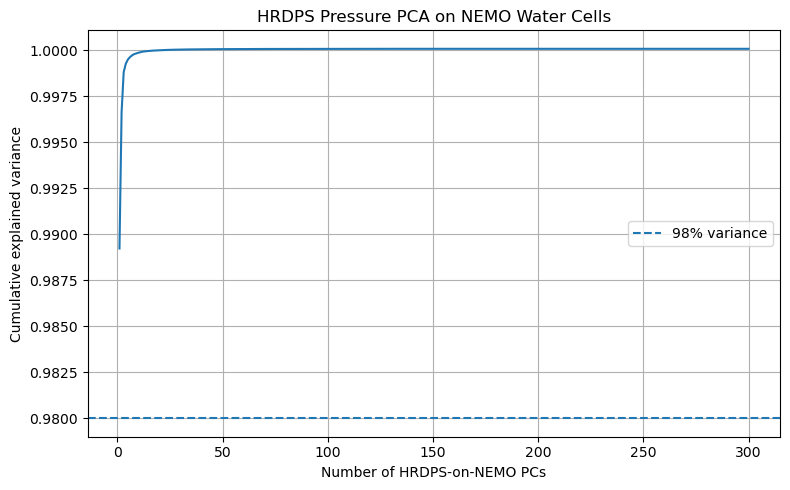

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1),hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold,linestyle="--",label="98% variance")
plt.xlabel("Number of HRDPS-on-NEMO PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS Pressure PCA on NEMO Water Cells")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]

print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:  ", hrdps_val_scores.shape)
print("HRDPS test scores: ", hrdps_test_scores.shape)

HRDPS train scores: (23360, 1)
HRDPS val scores:   (8744, 1)
HRDPS test scores:  (8760, 1)


In [29]:
max_canrcm_pcs = min(100,X_canrcm_train.shape[0] - 1,X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs,svd_solver="randomized",random_state=0)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

In [30]:
canrcm_pc_candidates = range(1,max_canrcm_pcs + 1)
val_r2_scores = []
for n_canrcm_pcs_candidate in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:,:n_canrcm_pcs_candidate]
    X_val_pc = canrcm_val_scores_all[:,:n_canrcm_pcs_candidate]
    model = LinearRegression()
    model.fit(X_train_pc,hrdps_train_scores)
    hrdps_val_scores_pred_candidate = model.predict(X_val_pc)
    val_r2 = r2_score(hrdps_val_scores,hrdps_val_scores_pred_candidate,multioutput="variance_weighted")
    val_r2_scores.append(val_r2)
val_r2_scores = np.array(val_r2_scores)

best_index = np.nanargmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]
best_val_r2 = val_r2_scores[best_index]

print("Best number of CanRCM PCs:", n_canrcm_pcs)

Best number of CanRCM PCs: 89


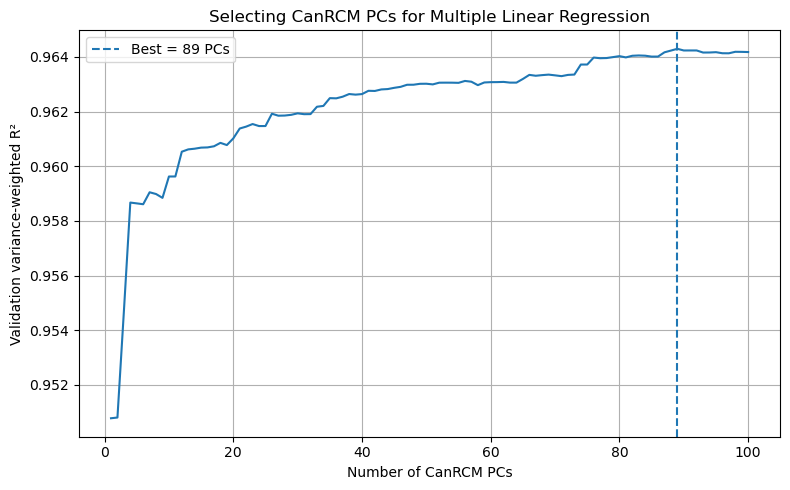

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates),val_r2_scores)
plt.axvline(n_canrcm_pcs,linestyle="--",label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting CanRCM PCs for Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
X_train_pc_final = canrcm_train_scores_all[:,:n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:,:n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:,:n_canrcm_pcs]

In [33]:
canrcm_pc_scaler = StandardScaler()
hrdps_pc_scaler = StandardScaler()

X_train_nn = canrcm_pc_scaler.fit_transform(X_train_pc_final).astype(np.float32)
X_val_nn = canrcm_pc_scaler.transform(X_val_pc_final).astype(np.float32)
X_test_nn = canrcm_pc_scaler.transform(X_test_pc_final).astype(np.float32)

Y_train_nn = hrdps_pc_scaler.fit_transform(hrdps_train_scores).astype(np.float32)
Y_val_nn = hrdps_pc_scaler.transform(hrdps_val_scores).astype(np.float32)
Y_test_nn = hrdps_pc_scaler.transform(hrdps_test_scores).astype(np.float32)

print("Scaled training input shape:", X_train_nn.shape)
print("Scaled validation input shape:", X_val_nn.shape)
print("Scaled test input shape:", X_test_nn.shape)

print("Scaled training target shape:", Y_train_nn.shape)
print("Scaled validation target shape:", Y_val_nn.shape)
print("Scaled test target shape:", Y_test_nn.shape)

print("Maximum absolute scaled training input:", np.abs(X_train_nn).max())
print("Maximum absolute scaled training target:", np.abs(Y_train_nn).max())

Scaled training input shape: (23360, 89)
Scaled validation input shape: (8744, 89)
Scaled test input shape: (8760, 89)
Scaled training target shape: (23360, 1)
Scaled validation target shape: (8744, 1)
Scaled test target shape: (8760, 1)
Maximum absolute scaled training input: 12.56741
Maximum absolute scaled training target: 4.458755


In [34]:
def build_pc_fcnn(n_input_pcs, n_output_pcs):
    regularizer = tf.keras.regularizers.l2(1e-3)

    inputs = tf.keras.layers.Input(shape=(n_input_pcs,), name="canrcm_pc_input")

    linear_out = tf.keras.layers.Dense(n_output_pcs, name="linear_branch")(inputs)

    x = tf.keras.layers.Dense(64, activation="gelu", kernel_regularizer=regularizer, name="dense_1")(inputs)
    x = tf.keras.layers.Dropout(0.3, name="dropout_1")(x)
    x = tf.keras.layers.Dense(32, activation="gelu", kernel_regularizer=regularizer, name="dense_2")(x)
    x = tf.keras.layers.Dropout(0.3, name="dropout_2")(x)

    nonlinear_out = tf.keras.layers.Dense(n_output_pcs, name="nonlinear_branch")(x)

    outputs = tf.keras.layers.Add(name="hrdps_pc_output")([linear_out, nonlinear_out])

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="canrcm_to_hrdps_pc_fcnn")

    return model

In [35]:
n_canrcm_pcs = X_train_nn.shape[1]
n_hrdps_pcs = Y_train_nn.shape[1]

In [36]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

pc_fcnn = build_pc_fcnn(n_input_pcs=n_canrcm_pcs,n_output_pcs=n_hrdps_pcs,)
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4,clipnorm=1.0,)
pc_fcnn.compile(optimizer=optimizer,loss="mse",metrics=[tf.keras.metrics.MeanAbsoluteError(name="pc_mae")],)
pc_fcnn.summary()

Model: "canrcm_to_hrdps_pc_fcnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ canrcm_pc_input     │ (None, 89)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      5,760 │ canrcm_pc_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ linear_branch       │ (None, 1)         │         90 │ canrcm_pc_input[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nonlinear_branch    │ (None, 1)         │         33 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hrdps_pc_output     │ (None, 1)         │          0 │ linear_branch[0]… │
│ (Add)               │                   │            │ nonlinear_branch… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,963 (31.11 KB)

 Trainable params: 7,963 (31.11 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
fcnn_output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/PCA_FCNN_All"
os.makedirs(fcnn_output_dir, exist_ok=True)
checkpoint_path = os.path.join(fcnn_output_dir, "best_pressure_pc_fcnn.keras")

In [38]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=18,
        min_delta=1e-5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=6,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

In [39]:
history = pc_fcnn.fit(
    X_train_nn,
    Y_train_nn,
    validation_data=(X_val_nn, Y_val_nn),
    epochs=300,
    batch_size=32,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/300

Epoch 1: val_loss improved from None to 0.34702, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/PCA_FCNN_All/best_pressure_pc_fcnn.keras

Epoch 1: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/PCA_FCNN_All/best_pressure_pc_fcnn.keras
730/730 - 5s - 7ms/step - loss: 1.7349 - pc_mae: 0.9223 - val_loss: 0.3470 - val_pc_mae: 0.3766 - learning_rate: 3.0000e-04
Epoch 2/300

Epoch 2: val_loss improved from 0.34702 to 0.18394, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/PCA_FCNN_All/best_pressure_pc_fcnn.keras

Epoch 2: finished saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/PCA_FCNN_All/best_pressure_pc_fcnn.keras
730/730 - 3s - 4ms/step - loss: 0.3984 - pc_mae: 0.4076 - val_loss: 0.1839 - val_pc_mae: 0.2270 - learning_rate: 3.0000e-04
Epoch 3/300

Epoch 3: val_loss improved from 0.18394 to 0.14101, saving model to /ocean/dtaneja/MOAD/analysis-dishika/notebooks/PCA_FCNN_All/best_pressure_pc_fcnn.keras

E

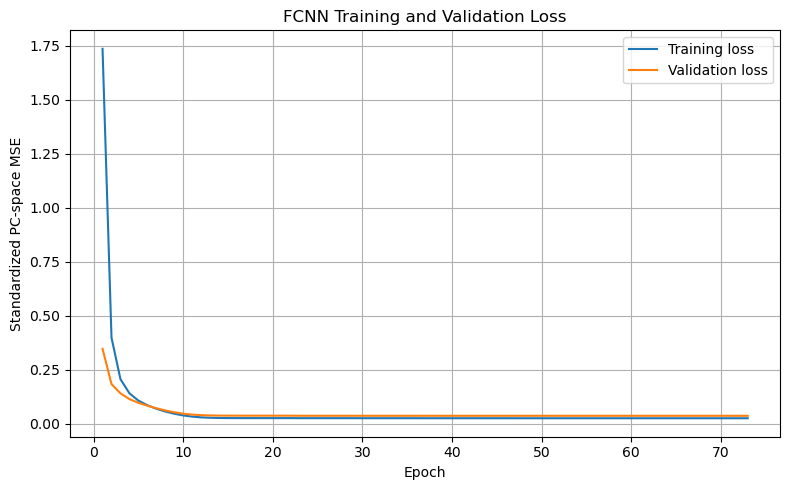

In [40]:
epochs_ran = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["loss"], label="Training loss")
plt.plot(epochs_ran, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Standardized PC-space MSE")
plt.title("FCNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
best_pc_fcnn = tf.keras.models.load_model(
    checkpoint_path,
    compile=False,
)

def predict_hrdps_pc_scores(model, X_scaled, scaler):
    predicted_scores_scaled = model.predict(X_scaled,batch_size=256,verbose=1,)
    predicted_scores = scaler.inverse_transform(predicted_scores_scaled)
    return predicted_scores.astype(np.float32)

hrdps_val_scores_pred = predict_hrdps_pc_scores(
    best_pc_fcnn,
    X_val_nn,
    hrdps_pc_scaler,
)

hrdps_test_scores_pred = predict_hrdps_pc_scores(
    best_pc_fcnn,
    X_test_nn,
    hrdps_pc_scaler,
)

print("Predicted validation PC shape:", hrdps_val_scores_pred.shape)
print("Predicted test PC shape:", hrdps_test_scores_pred.shape)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted validation PC shape: (8744, 1)
Predicted test PC shape: (8760, 1)


In [42]:
def reconstruct_hrdps_field(pc_scores, pca_model, number_of_pcs):
    selected_components = pca_model.components_[:number_of_pcs, :]
    reconstructed_field = pc_scores @ selected_components + pca_model.mean_
    return reconstructed_field

hrdps_val_reconstructed_pred = reconstruct_hrdps_field(hrdps_val_scores_pred, pca_hrdps, n_hrdps_pcs)
hrdps_test_reconstructed_pred = reconstruct_hrdps_field(hrdps_test_scores_pred, pca_hrdps, n_hrdps_pcs)

print("Reconstructed validation field shape:", hrdps_val_reconstructed_pred.shape)
print("Reconstructed test field shape:", hrdps_test_reconstructed_pred.shape)

Reconstructed validation field shape: (8744, 81383)
Reconstructed test field shape: (8760, 81383)


In [43]:
def calculate_field_metrics(actual, predicted, label):
    rmse = np.sqrt(np.mean((predicted - actual) ** 2, dtype=np.float64))
    mae = np.mean(np.abs(predicted - actual), dtype=np.float64)
    bias = np.mean(predicted - actual, dtype=np.float64)
    r2 = r2_score(actual, predicted, multioutput="variance_weighted")
    normalized_rmse = rmse / np.std(actual, ddof=0)

    print(f"\n{label}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"Bias: {bias:.2f}")
    print(f"R²: {r2:.2f}")
    print(f"Normalized RMSE: {normalized_rmse:.2f}")

    return {
        "RMSE": rmse,
        "MAE": mae,
        "Bias": bias,
        "R2": r2,
        "Normalized_RMSE": normalized_rmse,
    }

validation_field_metrics = calculate_field_metrics(
    X_hrdps_val,
    hrdps_val_reconstructed_pred,
    "Validation field metrics",
)

test_field_metrics = calculate_field_metrics(
    X_hrdps_test,
    hrdps_test_reconstructed_pred,
    "Test field metrics",
)


Validation field metrics
RMSE: 176.70
MAE: 129.24
Bias: 14.78
R²: 0.95
Normalized RMSE: 0.22

Test field metrics
RMSE: 143.93
MAE: 104.90
Bias: 8.57
R²: 0.96
Normalized RMSE: 0.20


In [44]:
def nemo_vector_to_map(vector):
    nemo_map = np.full(water_mask.shape, np.nan, dtype=np.float32)
    nemo_map[valid_nemo_j, valid_nemo_i] = vector
    return nemo_map

def plot_actual_predicted_error(time_index, X_actual, X_predicted, times):
    if time_index < 0 or time_index >= X_actual.shape[0]:
        raise IndexError(f"time_index must be between 0 and {X_actual.shape[0] - 1}.")

    actual_map = nemo_vector_to_map(X_actual[time_index])
    predicted_map = nemo_vector_to_map(X_predicted[time_index])
    error_map = predicted_map - actual_map

    shared_min = np.nanmin(np.stack([actual_map, predicted_map]))
    shared_max = np.nanmax(np.stack([actual_map, predicted_map]))
    error_limit = np.nanmax(np.abs(error_map))

    if error_limit == 0:
        error_limit = 1e-6

    timestamp = pd.Timestamp(times[time_index])

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))

    p0 = axes[0].pcolormesh(actual_map, shading="auto", vmin=shared_min, vmax=shared_max)
    axes[0].set_title(f"Actual HRDPS on NEMO Grid\n{timestamp}")
    plt.colorbar(p0, ax=axes[0], label="Pressure")

    p1 = axes[1].pcolormesh(predicted_map, shading="auto", vmin=shared_min, vmax=shared_max)
    axes[1].set_title(f"Predicted PCA + FCNN\n{timestamp}")
    plt.colorbar(p1, ax=axes[1], label="Pressure")

    p2 = axes[2].pcolormesh(error_map, shading="auto", cmap="RdBu_r", vmin=-error_limit, vmax=error_limit)
    axes[2].set_title(f"Predicted − Actual\n{timestamp}")
    plt.colorbar(p2, ax=axes[2], label="Pressure Error")

    for ax in axes:
        ax.set_xlabel("NEMO x index (i)")
        ax.set_ylabel("NEMO y index (j)")

    plt.tight_layout()
    plt.show()

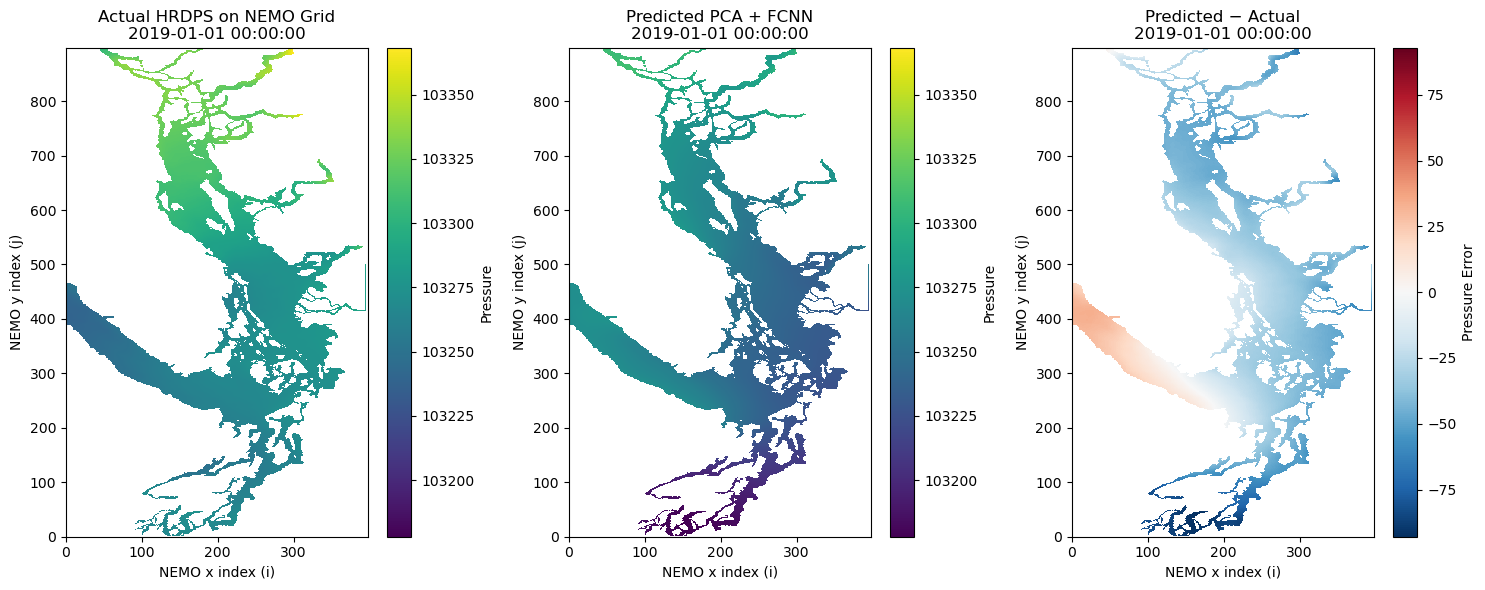

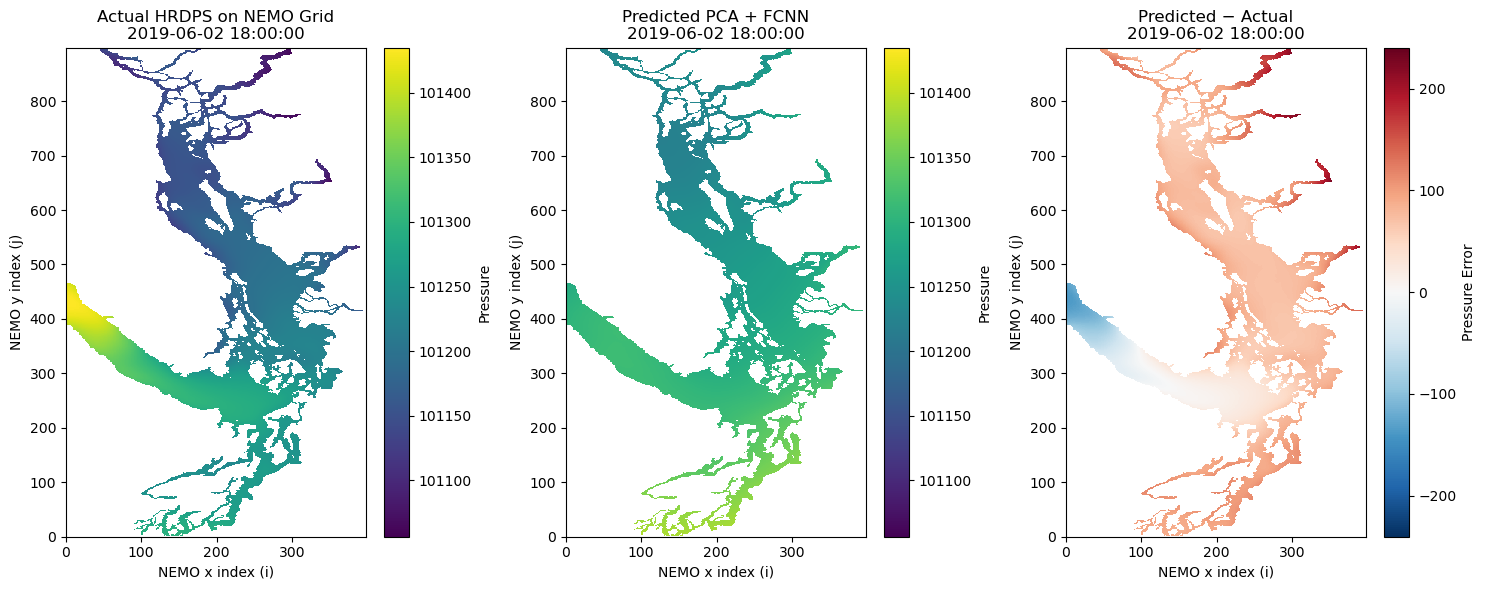

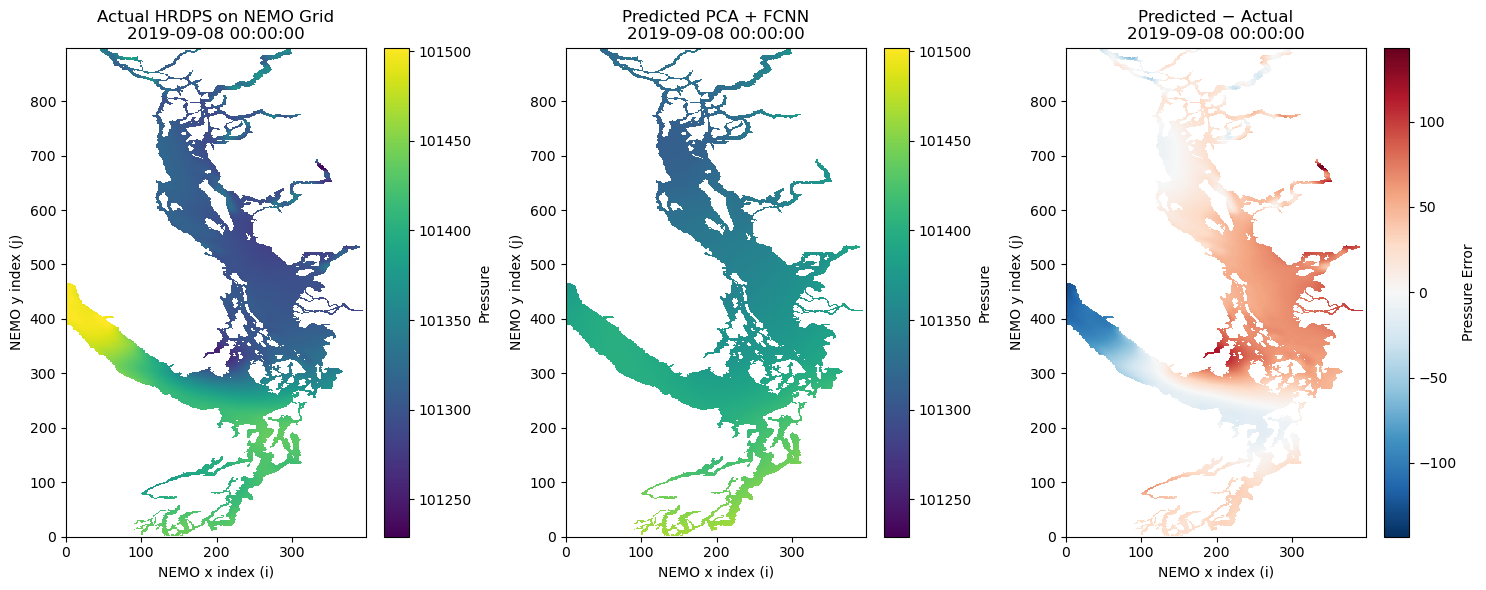

In [45]:
test_times = ds_hrdps_test["time_counter"].values

plot_actual_predicted_error(
    time_index=0,
    X_actual=X_hrdps_test,
    X_predicted=hrdps_test_reconstructed_pred,
    times=test_times
)

plot_actual_predicted_error(
    time_index=1222,
    X_actual=X_hrdps_test,
    X_predicted=hrdps_test_reconstructed_pred,
    times=test_times
)

plot_actual_predicted_error(
    time_index=2000,
    X_actual=X_hrdps_test,
    X_predicted=hrdps_test_reconstructed_pred,
    times=test_times
)

In [46]:
def make_spatial_mean_timeseries(actual_matrix, predicted_matrix, times):
    actual_mean = np.nanmean(actual_matrix, axis=1)
    predicted_mean = np.nanmean(predicted_matrix, axis=1)
    timeseries = pd.DataFrame(
        {
            "actual": actual_mean,
            "predicted": predicted_mean,
        },
        index=pd.to_datetime(times),
    )

    timeseries.index.name = "Date"

    return timeseries


val_times = ds_hrdps_val["time_counter"].values
test_times = ds_hrdps_test["time_counter"].values


pressure_timeseries_val = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_val,
    predicted_matrix=hrdps_val_reconstructed_pred,
    times=val_times,
)

pressure_timeseries_test = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_test,
    predicted_matrix=hrdps_test_reconstructed_pred,
    times=test_times,
)


print(pressure_timeseries_val.head())
print()
print(pressure_timeseries_val.tail())
print()
print(pressure_timeseries_test.head())
print()
print(pressure_timeseries_test.tail())

                            actual      predicted
Date                                             
2007-01-03 00:00:00  100324.007812  100187.179688
2007-01-03 03:00:00  100389.757812  100314.625000
2007-01-03 06:00:00  100489.937500  100396.515625
2007-01-03 09:00:00  100580.632812  100371.445312
2007-01-03 12:00:00  100444.945312  100306.296875

                            actual      predicted
Date                                             
2009-12-31 09:00:00  101882.078125  101663.500000
2009-12-31 12:00:00  101725.625000  101546.468750
2009-12-31 15:00:00  101502.523438  101265.578125
2009-12-31 18:00:00  101186.718750  100976.609375
2009-12-31 21:00:00  100791.906250  100716.296875

                            actual      predicted
Date                                             
2019-01-01 00:00:00  103280.007812  103249.945312
2019-01-01 03:00:00  103244.804688  103170.828125
2019-01-01 06:00:00  103168.765625  103120.476562
2019-01-01 09:00:00  103157.531250  103092.32031

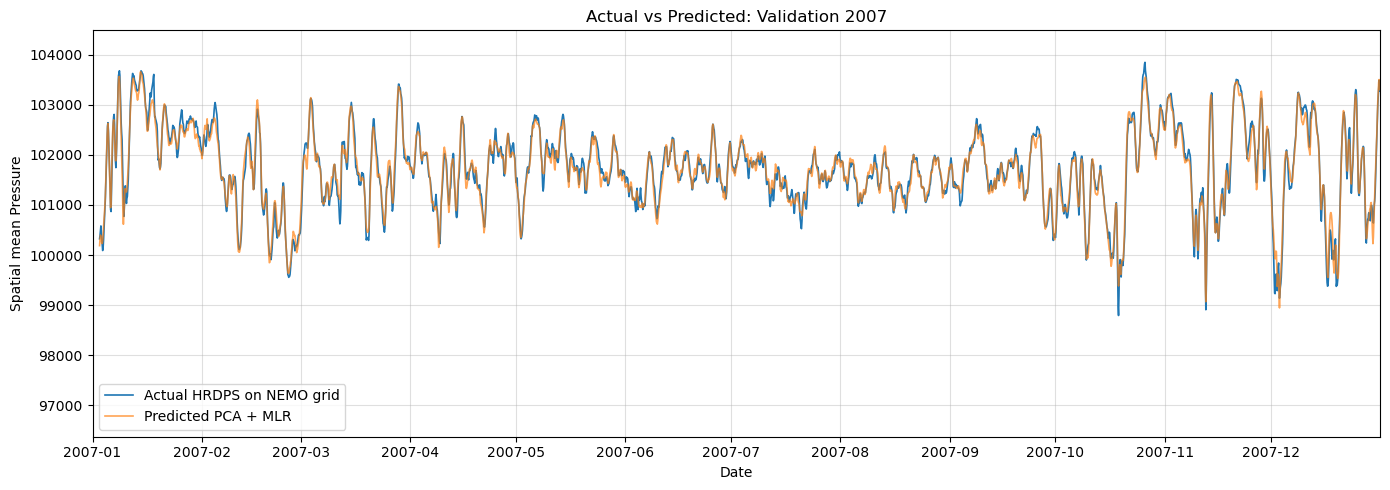

In [47]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pressure_timeseries_val.index,pressure_timeseries_val["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(pressure_timeseries_val.index,pressure_timeseries_val["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2007-01-01"),pd.Timestamp("2007-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Pressure")
ax.set_title("Actual vs Predicted: Validation 2007")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

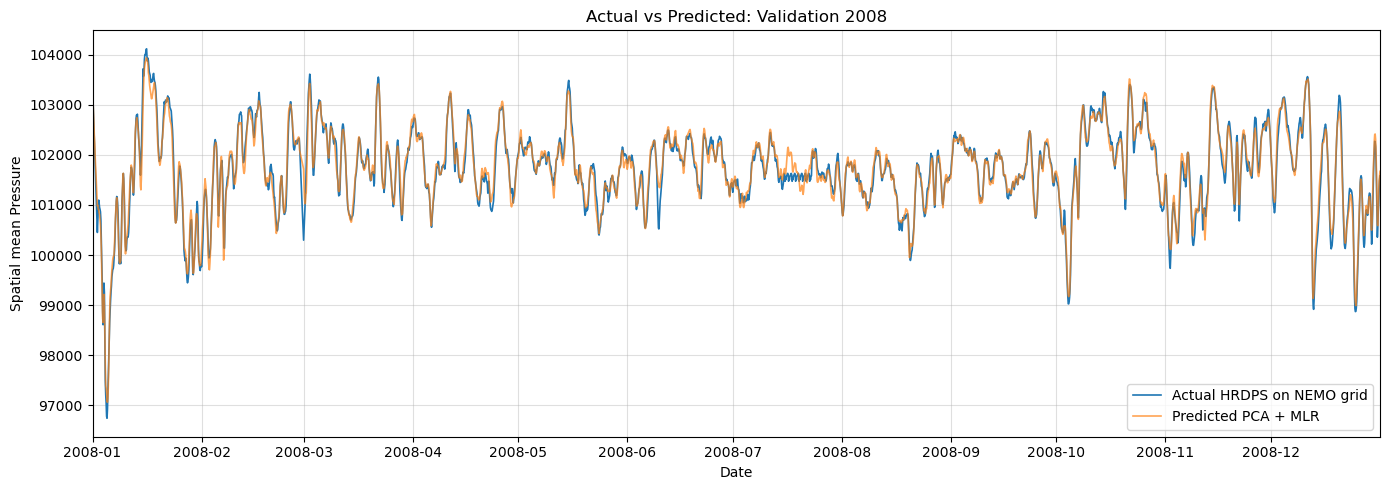

In [48]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pressure_timeseries_val.index,pressure_timeseries_val["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(pressure_timeseries_val.index,pressure_timeseries_val["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2008-01-01"),pd.Timestamp("2008-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Pressure")
ax.set_title("Actual vs Predicted: Validation 2008")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

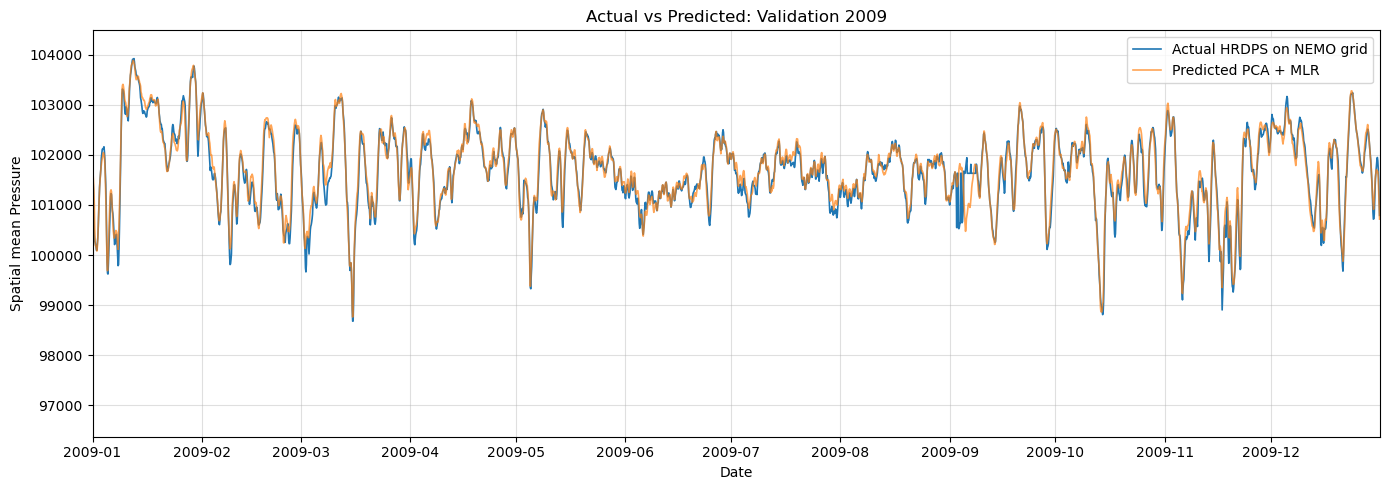

In [49]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pressure_timeseries_val.index,pressure_timeseries_val["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(pressure_timeseries_val.index,pressure_timeseries_val["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2009-01-01"),pd.Timestamp("2009-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Pressure")
ax.set_title("Actual vs Predicted: Validation 2009")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

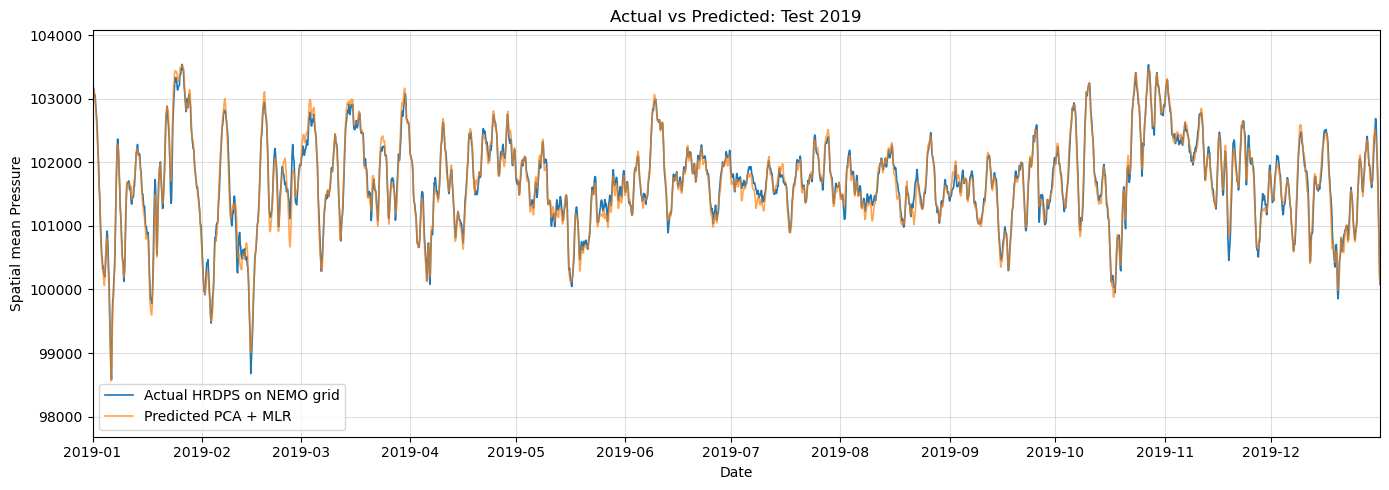

In [50]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pressure_timeseries_test.index, pressure_timeseries_test["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
ax.plot(pressure_timeseries_test.index, pressure_timeseries_test["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Pressure")
ax.set_title("Actual vs Predicted: Test 2019")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

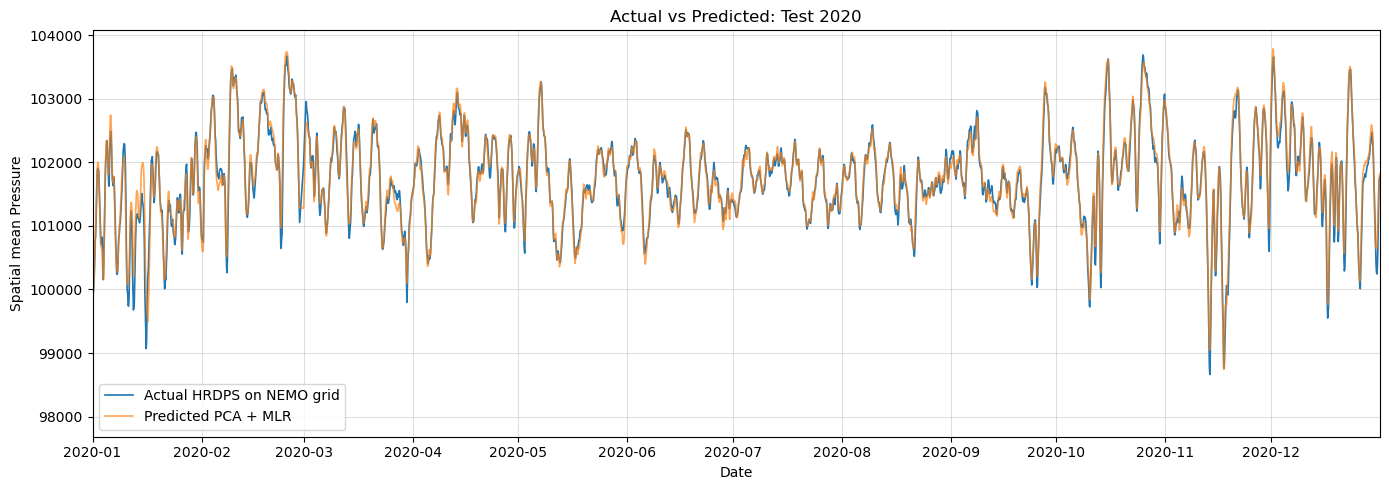

In [51]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pressure_timeseries_test.index, pressure_timeseries_test["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
ax.plot(pressure_timeseries_test.index, pressure_timeseries_test["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
ax.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Pressure")
ax.set_title("Actual vs Predicted: Test 2020")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

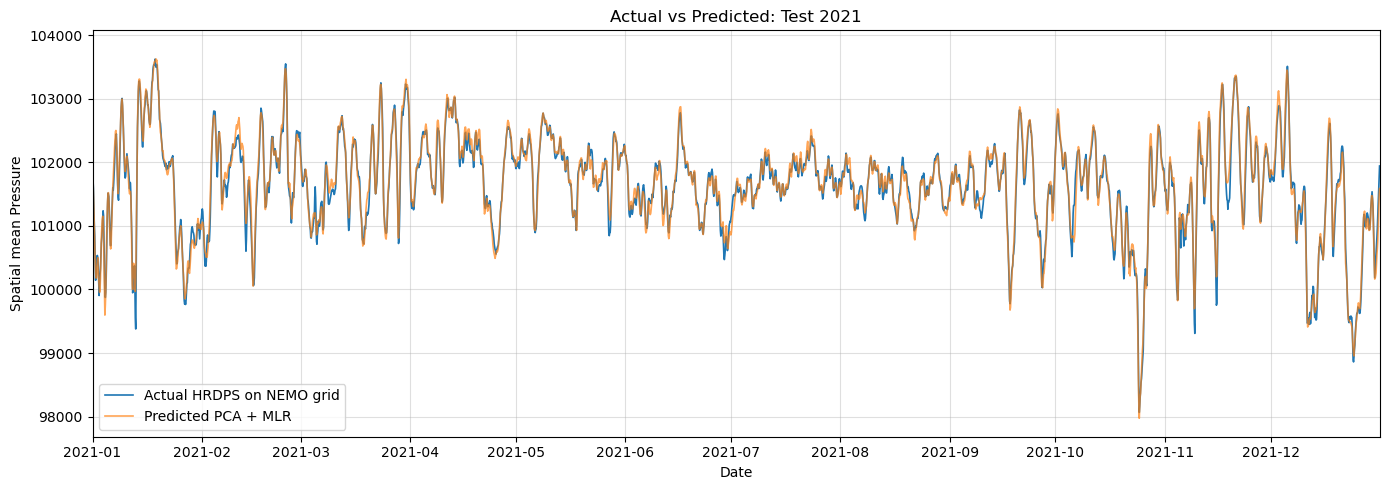

In [52]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pressure_timeseries_test.index, pressure_timeseries_test["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
ax.plot(pressure_timeseries_test.index, pressure_timeseries_test["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
ax.set_xlim(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Pressure")
ax.set_title("Actual vs Predicted: Test 2021")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Sand Heads j = 426 i = 293 matrix column = 44165
Halibut Bank j = 503 i = 261 matrix column = 53329
Sentry Shoal j = 707 i = 145 matrix column = 71870
Sand Heads RMSE: 130.9301 
Sand Heads Normalized RMSE: 0.1830 (18.30%)
Halibut Bank RMSE: 130.6642 
Halibut Bank Normalized RMSE: 0.1808 (18.08%)
Sentry Shoal RMSE: 161.4529 
Sentry Shoal Normalized RMSE: 0.2147 (21.47%)
     Station       RMSE  Normalized_RMSE  Normalized_RMSE_Percent
  Sand Heads 130.930064         0.183013                18.301310
Halibut Bank 130.664221         0.180826                18.082588
Sentry Shoal 161.452894         0.214660                21.466036

Average RMSE across the three stations: 141.0157
Average normalized RMSE across the three stations: 0.1928 (19.28%)


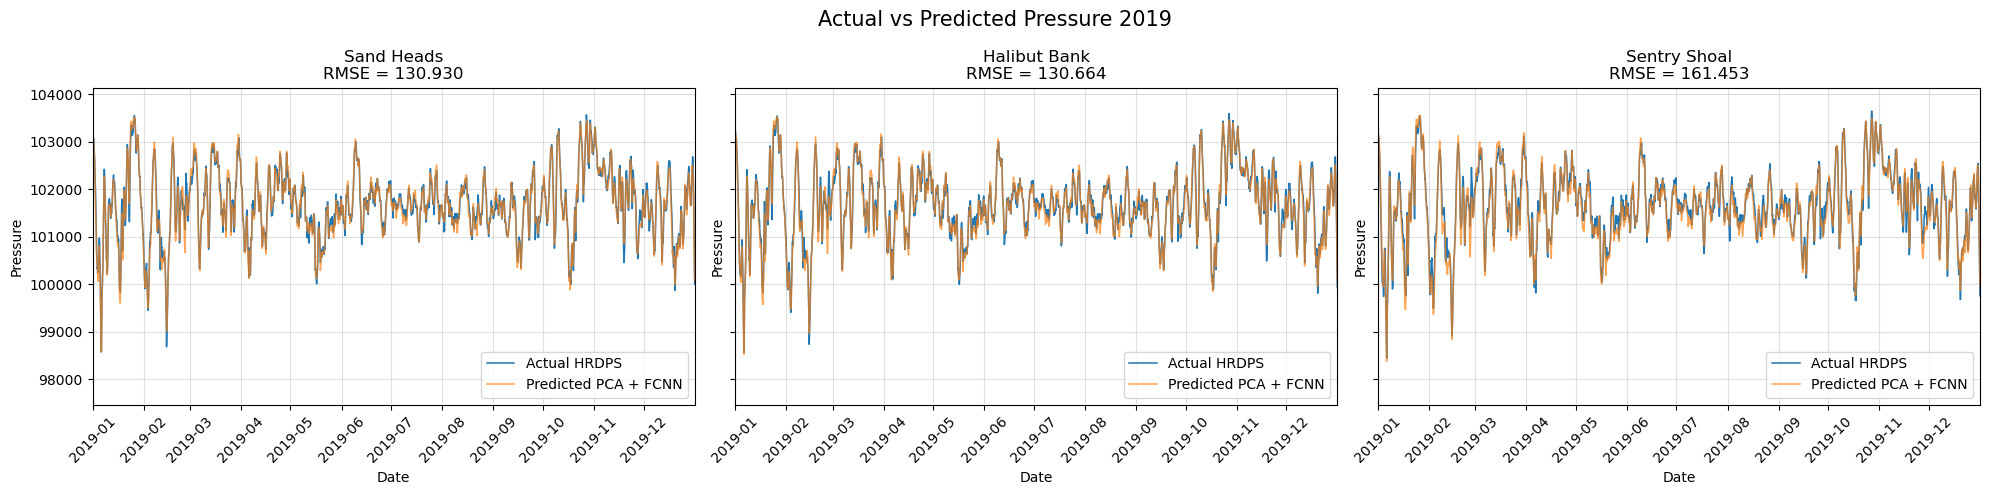

In [53]:
stations = {
    "Sand Heads": {"j": 426, "i": 293},
    "Halibut Bank": {"j": 503, "i": 261},
    "Sentry Shoal": {"j": 707, "i": 145}
}

def find_station_column(station_j, station_i):
    matches = np.where((valid_nemo_j == station_j) & (valid_nemo_i == station_i))[0]
    return int(matches[0])

for station_name, station_info in stations.items():
    column = find_station_column(station_info["j"], station_info["i"])
    stations[station_name]["column"] = column
    print(station_name, "j =", station_info["j"], "i =", station_info["i"], "matrix column =", column)

test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)

station_timeseries = {}
station_rmse = {}
station_normalized_rmse = {}

for station_name, station_info in stations.items():
    column = station_info["column"]

    actual = X_hrdps_test[:, column]
    predicted = hrdps_test_reconstructed_pred[:, column]

    station_df = pd.DataFrame(
        {
            "actual": actual,
            "predicted": predicted
        },
        index=test_times
    )

    station_df.index.name = "Date"

    rmse = np.sqrt(mean_squared_error(station_df["actual"], station_df["predicted"]))
    actual_std = np.std(station_df["actual"], ddof=0)
    normalized_rmse = rmse / actual_std

    station_timeseries[station_name] = station_df
    station_rmse[station_name] = rmse
    station_normalized_rmse[station_name] = normalized_rmse

    print(f"{station_name} RMSE: {rmse:.4f} ")
    print(f"{station_name} Normalized RMSE: {normalized_rmse:.4f} ({normalized_rmse * 100:.2f}%)")

station_rmse_table = pd.DataFrame(
    {
        "Station": list(station_rmse.keys()),
        "RMSE": list(station_rmse.values()),
        "Normalized_RMSE": list(station_normalized_rmse.values())
    }
)

station_rmse_table["Normalized_RMSE_Percent"] = station_rmse_table["Normalized_RMSE"] * 100

average_station_rmse = station_rmse_table["RMSE"].mean()
average_station_normalized_rmse = station_rmse_table["Normalized_RMSE"].mean()

print(station_rmse_table.to_string(index=False))
print(f"\nAverage RMSE across the three stations: {average_station_rmse:.4f}")
print(f"Average normalized RMSE across the three stations: {average_station_normalized_rmse:.4f} ({average_station_normalized_rmse * 100:.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, (station_name, station_df) in zip(axes, station_timeseries.items()):
    ax.plot(
        station_df.index,
        station_df["actual"],
        label="Actual HRDPS",
        linewidth=1.1
    )

    ax.plot(
        station_df.index,
        station_df["predicted"],
        label="Predicted PCA + FCNN",
        linewidth=1.1,
        alpha=0.7
    )

    ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
    ax.set_xlabel("Date")
    ax.set_ylabel("Pressure")
    ax.set_title(f"{station_name}\nRMSE = {station_rmse[station_name]:.3f}")
    ax.legend()
    ax.grid(True, alpha=0.4)
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Actual vs Predicted Pressure 2019", fontsize=15)

plt.tight_layout()
plt.show()

In [54]:
hrdps_train_scores_pred = predict_hrdps_pc_scores(
    best_pc_fcnn,
    X_train_nn,
    hrdps_pc_scaler,
)

X_hrdps_train_pred = reconstruct_hrdps_field(
    hrdps_train_scores_pred,
    pca_hrdps,
    n_hrdps_pcs,
)

X_hrdps_val_pred = hrdps_val_reconstructed_pred
X_hrdps_test_pred = hrdps_test_reconstructed_pred

print("Predicted training field shape:", X_hrdps_train_pred.shape)
print("Predicted validation field shape:", X_hrdps_val_pred.shape)
print("Predicted test field shape:", X_hrdps_test_pred.shape)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted training field shape: (23360, 81383)
Predicted validation field shape: (8744, 81383)
Predicted test field shape: (8760, 81383)


In [55]:
train_times = pd.to_datetime(ds_hrdps_train["time_counter"].values)
val_times = pd.to_datetime(ds_hrdps_val["time_counter"].values)
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)

predicted_split_data = {
    "Validation": {"years": validation_years, "times": val_times, "values": X_hrdps_val_pred},
    "Training": {"years": train_years, "times": train_times, "values": X_hrdps_train_pred},
    "Test": {"years": test_years, "times": test_times, "values": X_hrdps_test_pred}
}

In [56]:
monthly_records = []

for split_name, split_data in predicted_split_data.items():
    predicted_spatial_mean = np.mean(split_data["values"], axis=1)
    predicted_timeseries = pd.DataFrame({"Predicted": predicted_spatial_mean}, index=split_data["times"])
    predicted_timeseries.index.name = "Date"
    split_monthly_averages = predicted_timeseries.groupby([predicted_timeseries.index.year, predicted_timeseries.index.month])["Predicted"].mean()

    for (year, month), monthly_average in split_monthly_averages.items():
        monthly_records.append({"Year": int(year), "Month": int(month), "Predicted_Monthly_Average": float(monthly_average), "Split": split_name})

predicted_monthly_averages = pd.DataFrame(monthly_records)
predicted_monthly_averages = predicted_monthly_averages.sort_values(["Year", "Month"]).reset_index(drop=True)
predicted_monthly_table = predicted_monthly_averages.pivot(index="Year", columns="Month", values="Predicted_Monthly_Average")
predicted_monthly_table = predicted_monthly_table.reindex(columns=range(1, 13))
predicted_monthly_table.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print("Predicted monthly average Pressure table:")
print(predicted_monthly_table.round(2).to_string())

Predicted monthly average Pressure table:
            Jan        Feb        Mar        Apr        May        Jun        Jul        Aug        Sep        Oct        Nov        Dec
Year                                                                                                                                    
2007  102377.11  101302.80  101801.36  101689.29  101819.99  101599.24  101613.52  101517.31  101665.76  101527.77  101964.48  101537.73
2008  101263.55  101738.94  101978.65  101916.98  101738.18  101854.66  101662.09  101368.07  101763.68  102026.77  101727.28  101577.82
2009  102368.85  101632.69  101662.02  101876.48  101687.80  101397.48  101660.37  101624.32  101614.71  101600.34  101321.83  101869.72
2010  100937.79  101392.61  101463.90  101212.22  101575.66  101719.62  101662.77  101450.91  101411.17  101541.80  101630.91  101002.68
2011  102042.12  101718.57  100956.33  101608.73  101559.91  101502.30  101612.28  101591.63  101577.09  101693.41  101404.49  102515.95

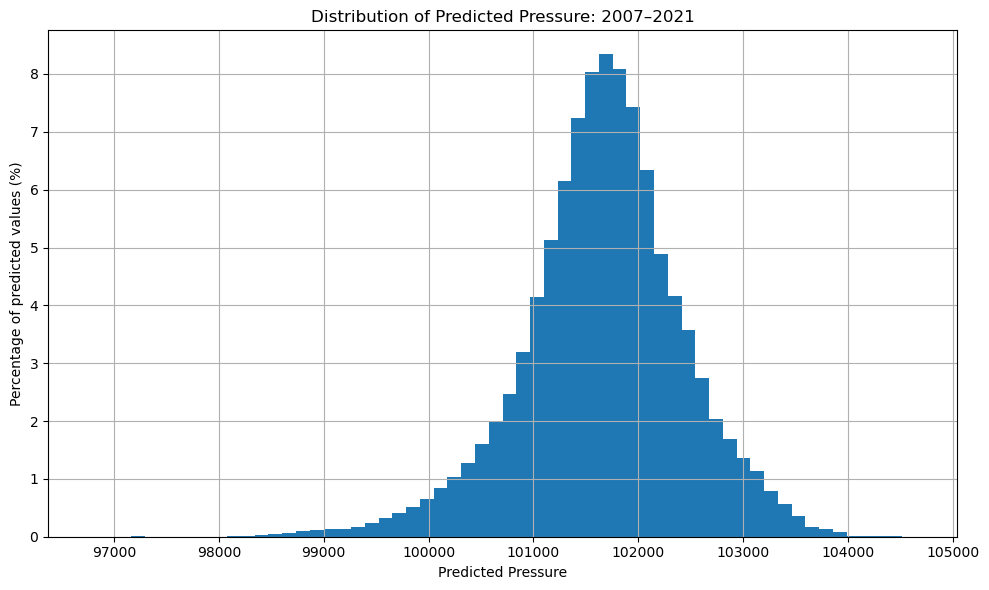

In [57]:
global_predicted_min = min(float(np.min(split_data["values"])) for split_data in predicted_split_data.values())
global_predicted_max = max(float(np.max(split_data["values"])) for split_data in predicted_split_data.values())
histogram_bins = np.linspace(global_predicted_min, global_predicted_max, 61)
all_year_histogram_counts = np.zeros(len(histogram_bins) - 1, dtype=np.int64)

for split_data in predicted_split_data.values():
    split_counts, _ = np.histogram(split_data["values"], bins=histogram_bins)
    all_year_histogram_counts += split_counts

all_year_histogram_percentage = 100 * all_year_histogram_counts / all_year_histogram_counts.sum()

plt.figure(figsize=(10, 6))
plt.stairs(all_year_histogram_percentage, histogram_bins, fill=True)
plt.xlabel("Predicted Pressure")
plt.ylabel("Percentage of predicted values (%)")
plt.title("Distribution of Predicted Pressure: 2007–2021")
plt.tight_layout()
plt.grid(True)
plt.show()

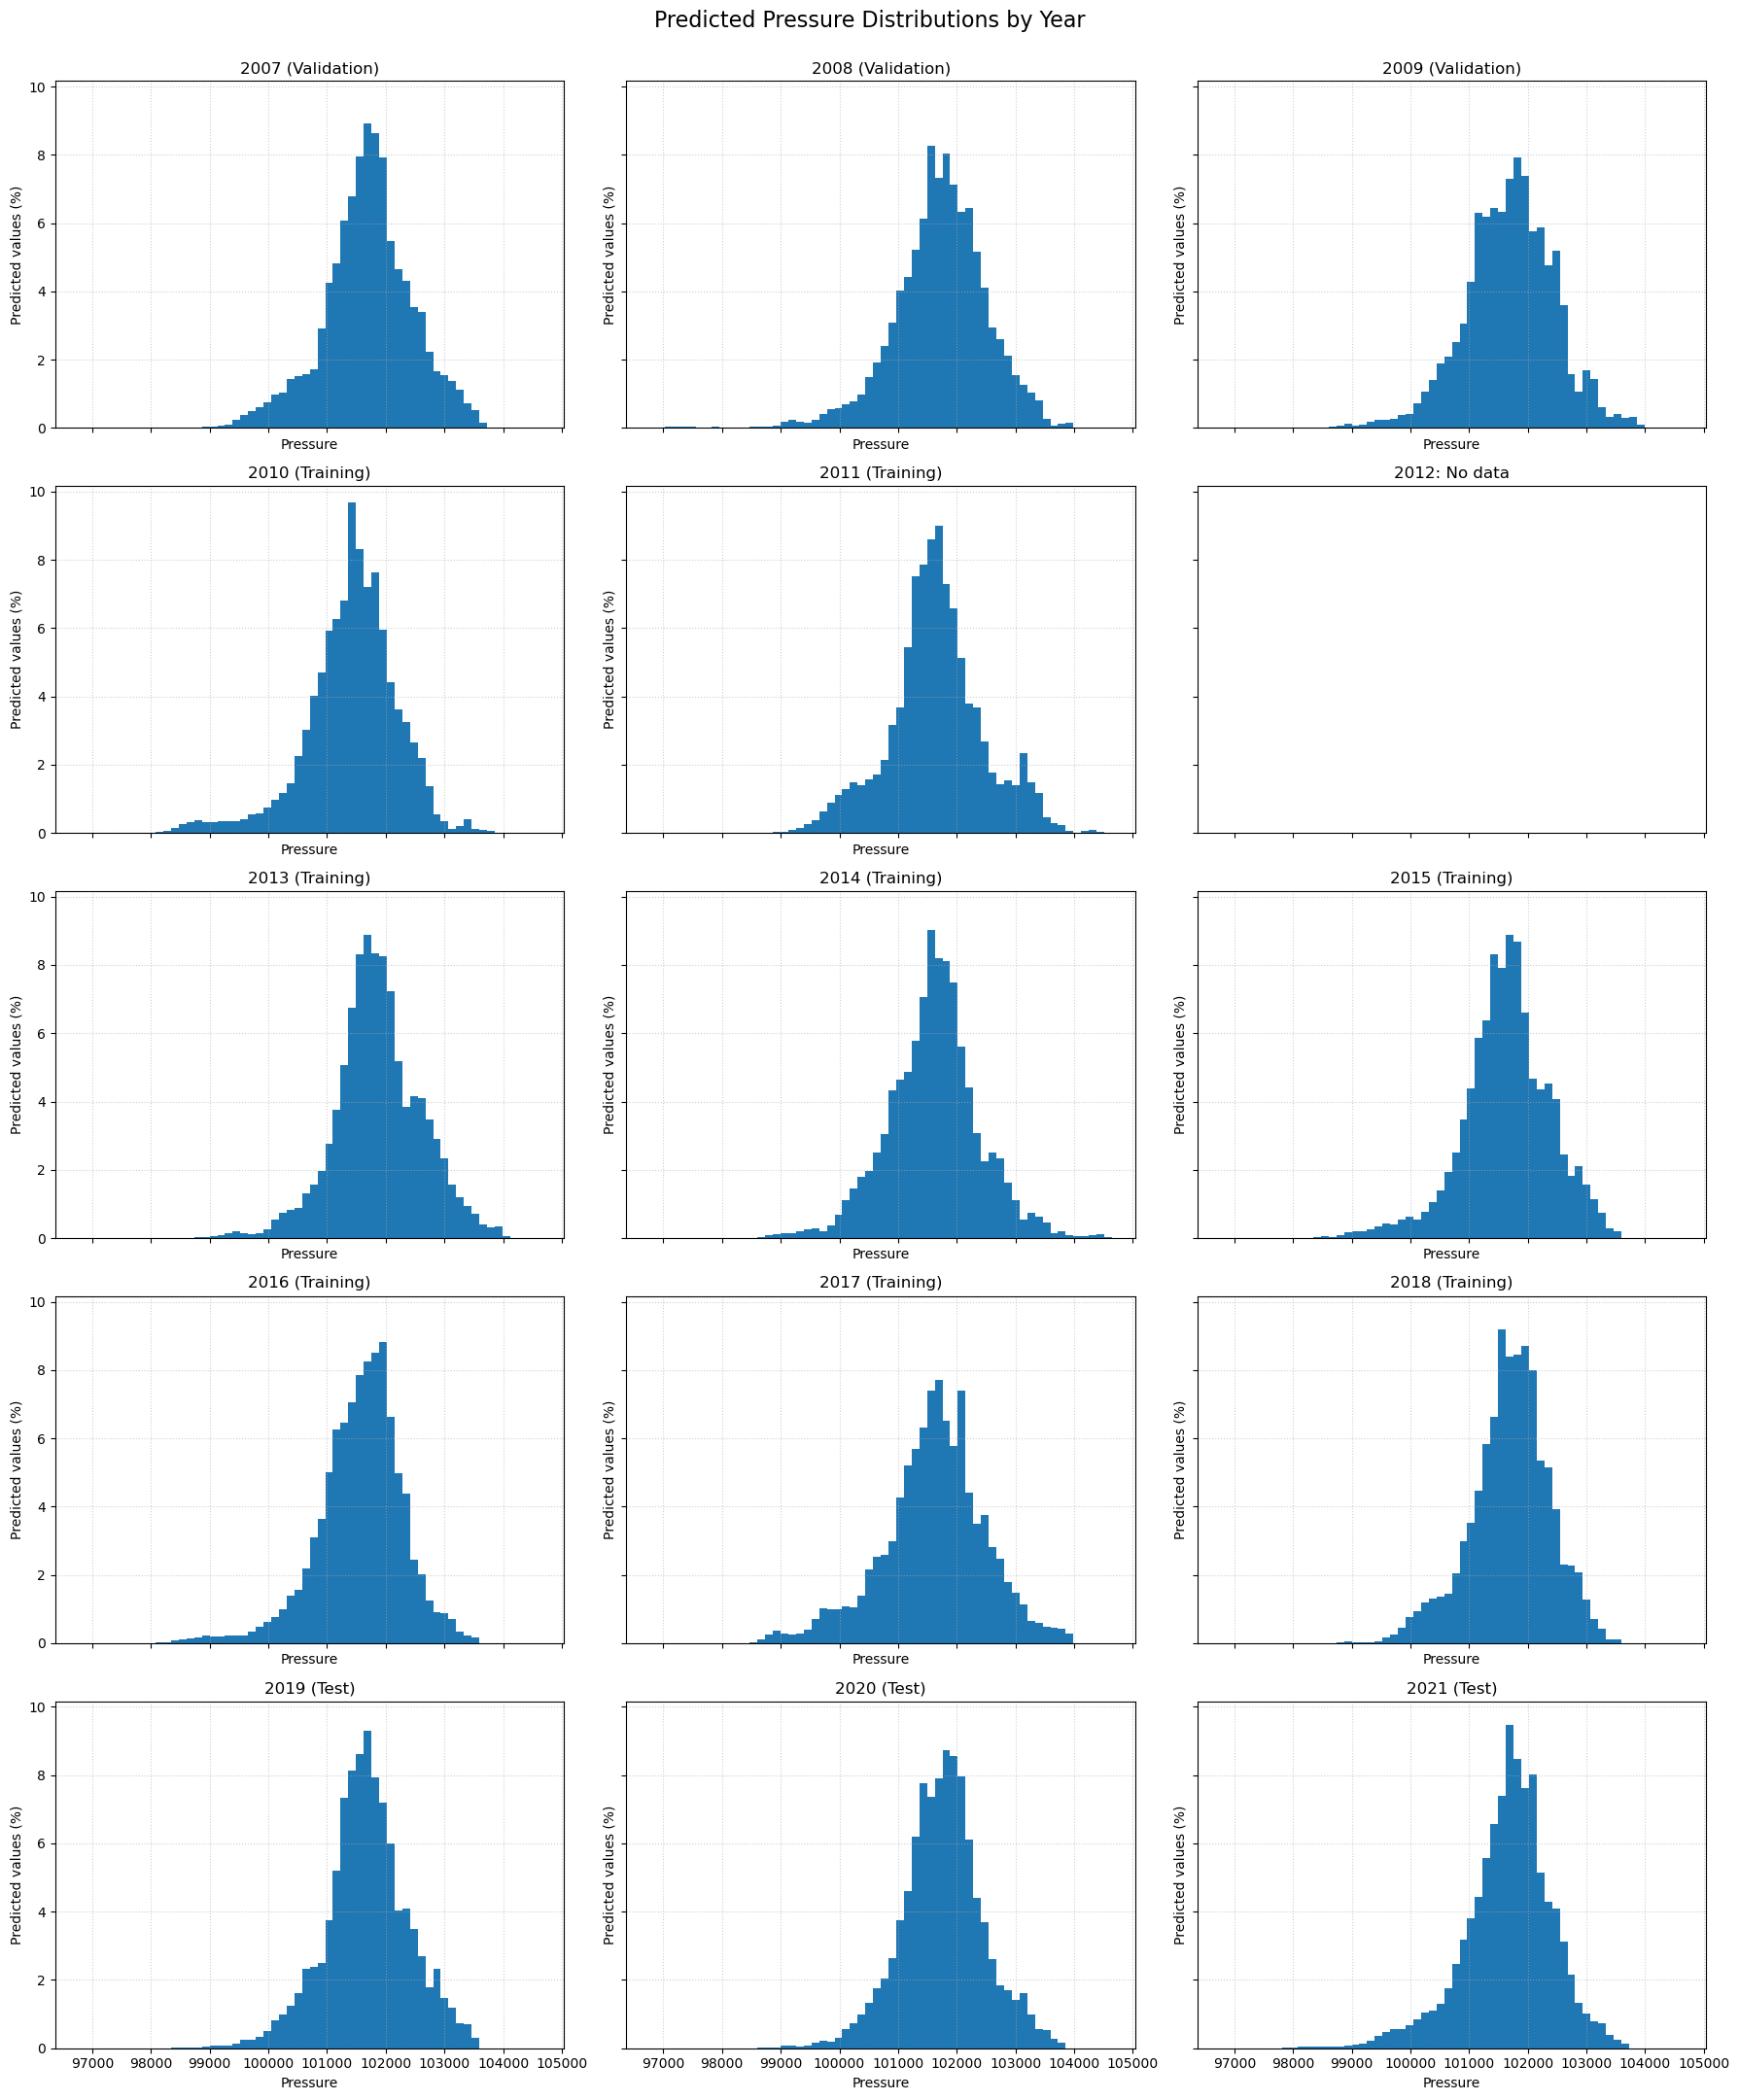

In [58]:
fig, axes = plt.subplots(5, 3, figsize=(18, 22), sharex=True, sharey=True)
axes = axes.ravel()

for ax, year in zip(axes, range(2007, 2022)):
    year_split_name = None
    year_split_data = None

    for split_name, split_data in predicted_split_data.items():
        if year in split_data["years"]:
            year_split_name = split_name
            year_split_data = split_data
            break

    year_positions = np.where(year_split_data["times"].year == year)[0]

    if len(year_positions) == 0:
        ax.set_title(f"{year}: No data")
        continue

    year_predictions = year_split_data["values"][year_positions[0]:year_positions[-1] + 1]
    year_histogram_counts, _ = np.histogram(year_predictions, bins=histogram_bins)
    year_histogram_percentage = 100 * year_histogram_counts / year_histogram_counts.sum()

    ax.stairs(year_histogram_percentage, histogram_bins, fill=True)
    ax.set_title(f"{year} ({year_split_name})")
    ax.set_xlabel("Pressure")
    ax.set_ylabel("Predicted values (%)")
    ax.grid(True, linestyle=":", alpha=0.6)

fig.suptitle("Predicted Pressure Distributions by Year", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [59]:
validation_year = 2008
spatial_step = 5

val_times = pd.to_datetime(ds_hrdps_val["time_counter"].values)
year_time_mask = val_times.year == validation_year

if not np.any(year_time_mask):
    raise ValueError(f"No validation data found for {validation_year}.")

X_actual_2008 = X_hrdps_val[year_time_mask]
X_predicted_2008 = hrdps_val_reconstructed_pred[year_time_mask]

print("Actual 2008 shape:", X_actual_2008.shape)
print("Predicted 2008 shape:", X_predicted_2008.shape)
print("Number of 2008 timestamps:", np.sum(year_time_mask))

if X_actual_2008.shape != X_predicted_2008.shape:
    raise ValueError("Actual and predicted validation matrices do not have matching shapes.")

selected_columns = np.arange(0, X_actual_2008.shape[1], spatial_step)

actual_selected = X_actual_2008[:, selected_columns]
predicted_selected = X_predicted_2008[:, selected_columns]

rmse_every_5th_point = np.sqrt(
    np.nanmean(
        (predicted_selected - actual_selected) ** 2,
        axis=0
    )
)

selected_nemo_j = valid_nemo_j[selected_columns]
selected_nemo_i = valid_nemo_i[selected_columns]

print("Number of selected spatial points:", len(selected_columns))
print("Mean RMSE across selected points:", np.nanmean(rmse_every_5th_point))
print("Minimum RMSE:", np.nanmin(rmse_every_5th_point))
print("Maximum RMSE:", np.nanmax(rmse_every_5th_point))

Actual 2008 shape: (2920, 81383)
Predicted 2008 shape: (2920, 81383)
Number of 2008 timestamps: 2920
Number of selected spatial points: 16277
Mean RMSE across selected points: 172.575
Minimum RMSE: 155.98193
Maximum RMSE: 287.5106


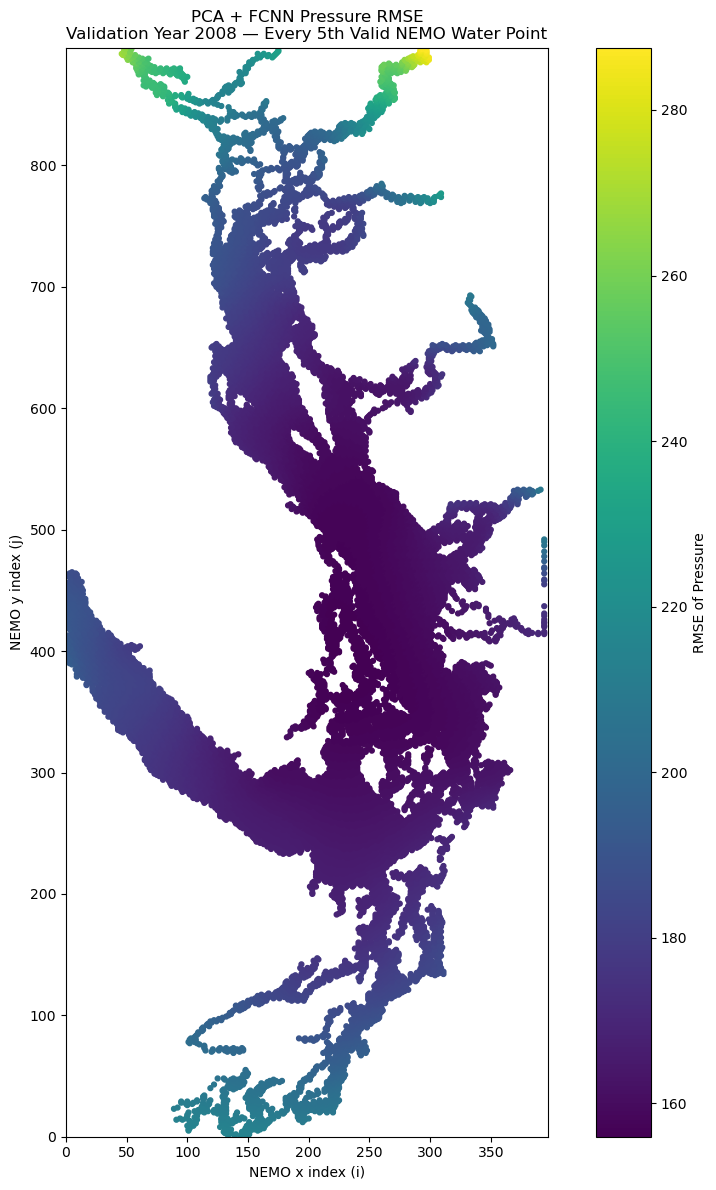

In [60]:
fig, ax = plt.subplots(figsize=(10, 12))

scatter = ax.scatter(
    selected_nemo_i,
    selected_nemo_j,
    c=rmse_every_5th_point,
    cmap="viridis",
    s=12,
    marker="o"
)

colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("RMSE of Pressure")

ax.set_xlabel("NEMO x index (i)")
ax.set_ylabel("NEMO y index (j)")
ax.set_title(
    "PCA + FCNN Pressure RMSE\n"
    "Validation Year 2008 — Every 5th Valid NEMO Water Point"
)

ax.set_xlim(0, water_mask.shape[1] - 1)
ax.set_ylim(0, water_mask.shape[0] - 1)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [61]:
rmse_every_5th_point_table = pd.DataFrame(
    {
        "Matrix_Column": selected_columns,
        "NEMO_j": selected_nemo_j,
        "NEMO_i": selected_nemo_i,
        "RMSE": rmse_every_5th_point
    }
)

print(rmse_every_5th_point_table.head(20).to_string(index=False))

 Matrix_Column  NEMO_j  NEMO_i       RMSE
             0       1     134 215.482864
             5       1     139 215.274719
            10       1     144 215.081741
            15       1     149 214.936600
            20       2     133 215.294052
            25       2     140 214.989502
            30       2     145 214.813889
            35       2     151 214.639618
            40       3     131 215.161423
            45       3     136 214.919601
            50       3     145 214.581009
            55       3     150 214.427048
            60       4     130 214.977173
            65       4     135 214.731430
            70       4     145 214.350784
            75       4     150 214.186356
            80       5     101 215.950302
            85       5     133 214.603134
            90       5     147 214.041122
            95       5     152 213.894073
